# Statistical analysis using multiple linear regression

A statistical analysis is made using multiple linear regression. The California housing dataset is used, and both numerical and categorical variables are included in the model.

## Importing and inspecting data

First the dataset is loaded and inspected to understand its structure and content.

In [24]:
import pandas as pd
from linear_regression import LinearRegression

df = pd.read_csv("housing.csv") 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [25]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [26]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Checking missing data

In [27]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### Results and cleaning data

Missing values are removed.

In [28]:
df = df.dropna()

X_num = df.drop(["median_house_value", "ocean_proximity"], axis=1).values
y = df["median_house_value"].values

cat = df["ocean_proximity"].values

model = LinearRegression(X_num, y)
model.fit()

In [29]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [30]:
model.n, model.d, model.variance(), model.standard_deviation(), model.rmse()

(20433,
 8,
 np.float64(4840189708.7438545),
 np.float64(69571.47194607754),
 np.float64(69556.14839566678))

## Results
The following statistics are reported:
- Sample size (n): 20433
- Number of features (d): 8
- Sample variance: 4840189708.7438545
- Standard deviation: 69571.47194607754
- Root Mean Squared Error (RMSE): 69556.14839566678

# VG section

Significance of the regression (F-test)

To evaluate whether the regression model as a whole is statistically significant,  
an F-test is performed. A low p-value indicates that the model explains a significant  
amount of the variation in the response variable.

In [31]:
model.f_test()

(np.float64(4478.347194849655), np.float64(0.0))

Significance of individual coefficients (t-tests) Each regression coefficient is tested individually using a t-test. This shows whether each feature contributes significantly to the model.

In [32]:
t_stats, p_vals = model.t_test()

for i in range(len(t_stats)):
    print(f"Beta {i}: t = {t_stats[i]:.4f}, p = {p_vals[i]:.4f}")

Beta 0: t = -57.0010, p = 0.0000
Beta 1: t = -59.5885, p = 0.0000
Beta 2: t = -62.7958, p = 0.0000
Beta 3: t = 26.6867, p = 0.0000
Beta 4: t = -10.3867, p = 0.0000
Beta 5: t = 16.4229, p = 0.0000
Beta 6: t = -35.4071, p = 0.0000
Beta 7: t = 6.3209, p = 0.0000
Beta 8: t = 119.5038, p = 0.0000


Confidence intervals for the regression coefficients
A 95% confidence interval is computed for each coefficient. This gives a range of plausible values for each parameter.

In [33]:
ci_95 = model.confidence_intervals(alpha=0.05)
ci_95

array([[-3.70868585e+06, -3.46210564e+06],
       [-4.41356684e+04, -4.13245725e+04],
       [-4.38366162e+04, -4.11828576e+04],
       [ 1.07285518e+03,  1.24294543e+03],
       [-9.80653967e+00, -6.69291047e+00],
       [ 1.00236191e+02,  1.27405223e+02],
       [-4.05105426e+01, -3.62606135e+01],
       [ 3.29094978e+01,  6.24932049e+01],
       [ 3.96365686e+04,  4.09584748e+04]])

In [34]:
ci_90 = model.confidence_intervals(alpha=0.10)
ci_90

array([[-3.68886263e+06, -3.48192887e+06],
       [-4.39096771e+04, -4.15505639e+04],
       [-4.36232737e+04, -4.13962002e+04],
       [ 1.08652918e+03,  1.22927144e+03],
       [-9.55622690e+00, -6.94322324e+00],
       [ 1.02420381e+02,  1.25221034e+02],
       [-4.01688797e+01, -3.66022764e+01],
       [ 3.52878091e+01,  6.01148935e+01],
       [ 3.97428401e+04,  4.08522033e+04]])

The coefficient of determination R2 shows how much of the variation in the response variable is explained by the model.

In [35]:
model.r_squared()

np.float64(0.6369116857335633)

## Pearson correlation matrix

To check for linear dependencies between variables,  
the Pearson correlation coefficient is computed for all pairs of features.

In [45]:
corr = model.pearson_matrix()
corr

array([[ 1.        , -0.92461611, -0.10935655,  0.04548017,  0.06960802,
         0.1002703 ,  0.05651277, -0.01555015],
       [-0.92461611,  1.        ,  0.01189907, -0.03666681, -0.06698283,
        -0.10899734, -0.07177419, -0.07962632],
       [-0.10935655,  0.01189907,  1.        , -0.3606283 , -0.32045104,
        -0.2957873 , -0.30276797, -0.11827772],
       [ 0.04548017, -0.03666681, -0.3606283 ,  1.        ,  0.9303795 ,
         0.85728125,  0.91899153,  0.19788152],
       [ 0.06960802, -0.06698283, -0.32045104,  0.9303795 ,  1.        ,
         0.87774674,  0.97972827, -0.00772285],
       [ 0.1002703 , -0.10899734, -0.2957873 ,  0.85728125,  0.87774674,
         1.        ,  0.9071859 ,  0.00508662],
       [ 0.05651277, -0.07177419, -0.30276797,  0.91899153,  0.97972827,
         0.9071859 ,  1.        ,  0.01343389],
       [-0.01555015, -0.07962632, -0.11827772,  0.19788152, -0.00772285,
         0.00508662,  0.01343389,  1.        ]])

## Including a categorical variable in the model

The categorical variable "ocean_proximity" is included using dummy encoding. This allows the regression model to handle non-numerical data.

In [37]:
model.d
model.beta.shape

(9,)

In [38]:
model.beta

array([-3.58539575e+06, -4.27301205e+04, -4.25097369e+04,  1.15790031e+03,
       -8.24972507e+00,  1.13820707e+02, -3.83855780e+01,  4.77013513e+01,
        4.02975217e+04])

Significance tests for the model including the categorical variable

In [39]:
model.confidence_intervals()

array([[-3.70868585e+06, -3.46210564e+06],
       [-4.41356684e+04, -4.13245725e+04],
       [-4.38366162e+04, -4.11828576e+04],
       [ 1.07285518e+03,  1.24294543e+03],
       [-9.80653967e+00, -6.69291047e+00],
       [ 1.00236191e+02,  1.27405223e+02],
       [-4.05105426e+01, -3.62606135e+01],
       [ 3.29094978e+01,  6.24932049e+01],
       [ 3.96365686e+04,  4.09584748e+04]])

## Summary
- F-test for overall model significance 
- t-tests for individual coefficients 
- Confidence intervals 
- Pearson correlation matrix 
- Handling of categorical variables 
- Regression including the categorical variable "ocean_proximity"

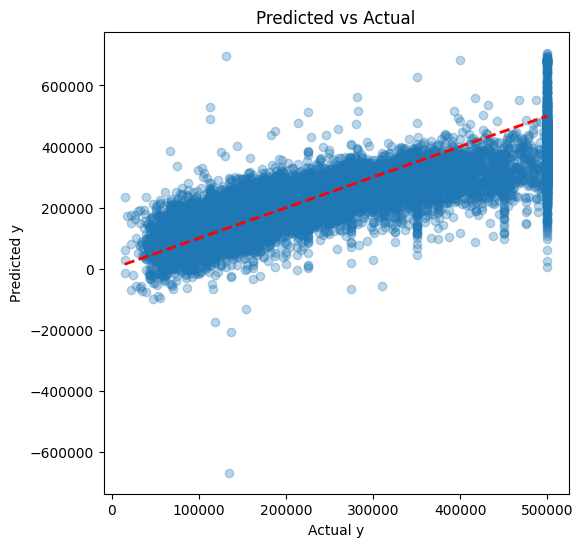

In [40]:
import matplotlib.pyplot as plt

y_hat = model.y_hat
y_true = model.y

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_hat, alpha=0.3)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()], 'r--', linewidth=2)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Predicted vs Actual")
plt.show()

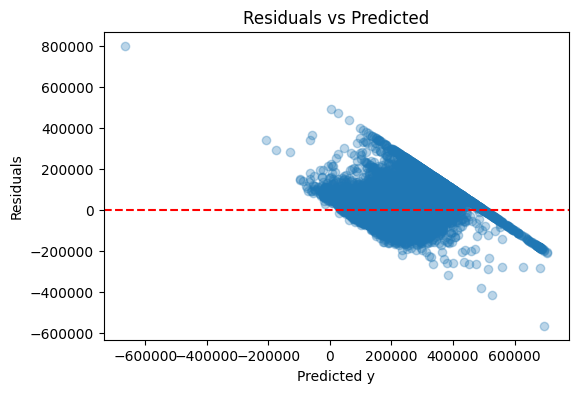

In [41]:
residuals = y_true - y_hat

plt.figure(figsize=(6,4))
plt.scatter(y_hat, residuals, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted y")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

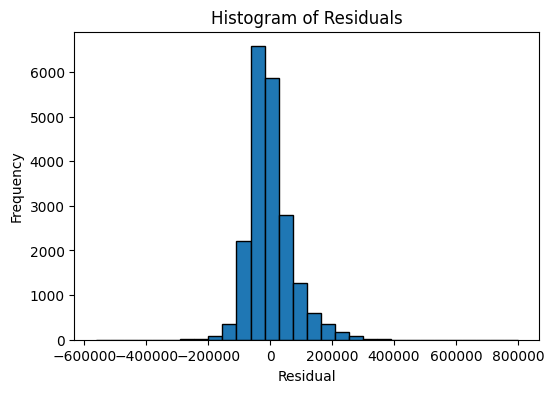

In [42]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, edgecolor='k')
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

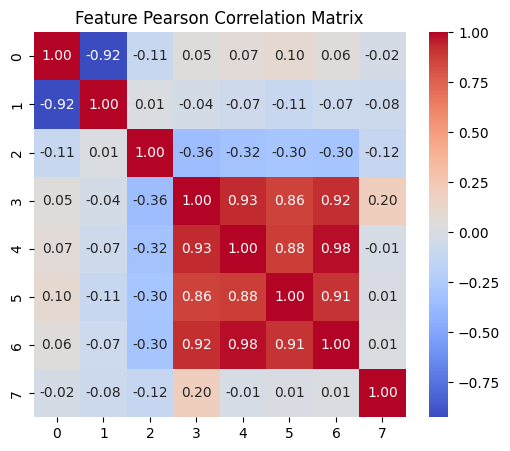

In [43]:
import seaborn as sns

corr = model.pearson_matrix()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Pearson Correlation Matrix")
plt.show()